## 1. Installing Packages

In [18]:
# Requires Python 3.11+.

# ! pip install -r requirements.txt
# ! python -m pip install statsmodels


## 2. Loading Packages

In [2]:
# Core data libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Statistical distributions and tests
from scipy import stats

# display() is available in Jupyter. The fallback keeps the code runnable as a script.
try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {
    "sales": "#17324D",
    "digital": "#147D92",
    "radio": "#E08E45",
    "tv": "#7A5195",
    "negative": "#B33A3A",
}

ALPHA = 0.05
print(f"Significance level: alpha = {ALPHA}")

Significance level: alpha = 0.05


## 3. Reading File/Data

In [3]:
import pandas as pd

file_path = 'Retail Sales Case Study.xlsx'

# 1. Define your strict manual schemas
# We use 'str' (string) for text/dates to avoid implicit parsing, and 'float64' for numbers
sales_schema = {
    'Timeframe': 'str',             # Read as string to avoid implicit datetime conversion
    'sales (Million $)': 'float64', 
    'Digital (Million $)': 'float64',
    'radio (Million $)': 'float64',
    'TV (Thousands $)': 'float64'
}

gdp_schema = {
    'QTR': 'str',
    'GDP % Change': 'float64'
}

# 2. Load the data using a try-except block to catch conversion errors
try:
    print("Attempting to load 'Retail Sales Case Study' sheet...")
    sales_raw = pd.read_excel(
        file_path, 
        sheet_name='Retail Sales Case Study', 
        dtype=sales_schema
    )
    print("Sales data loaded successfully with manual types!\n")
    
except ValueError as e:
    print(f"Exception Caught in Sales Data: A value violated the manual datatype rules.\nDetails: {e}\n")

try:
    print("Attempting to load 'GDP Change %' sheet...")
    gdp_raw = pd.read_excel(
        file_path, 
        sheet_name='GDP Change %', 
        dtype=gdp_schema
    )
    print("GDP data loaded successfully with manual types!\n")
    
except ValueError as e:
    print(f"Exception Caught in GDP Data: A value violated the manual datatype rules.\nDetails: {e}\n")

# Verify the final data types
print("--- Sales Data Types ---")
print(sales_raw.dtypes)

print("\n--- GDP Data Types ---")
print(gdp_raw.dtypes)

Attempting to load 'Retail Sales Case Study' sheet...
Sales data loaded successfully with manual types!

Attempting to load 'GDP Change %' sheet...
GDP data loaded successfully with manual types!

--- Sales Data Types ---
Timeframe                  str
sales (Million $)      float64
Digital (Million $)    float64
radio (Million $)      float64
TV (Thousands $)       float64
dtype: object

--- GDP Data Types ---
QTR                 str
GDP % Change    float64
dtype: object


In [4]:
display(sales_raw.head())
display(gdp_raw.head())

,Timeframe,sales (Million $),Digital (Million $),radio (Million $),TV (Thousands $)
0,2020-01-01 00:00:00,397.800,115.050,18.900,34.600
1,2020-02-01 00:00:00,187.200,22.250,19.650,22.550
2,2020-03-01 00:00:00,167.400,8.600,22.950,34.650
3,2020-04-01 00:00:00,333.000,75.750,20.650,29.250
4,2020-05-01 00:00:00,232.200,90.400,5.400,29.200


,QTR,GDP % Change
0,2020 - Q1,-0.046
1,2020 - Q2,-0.299
2,2020 - Q3,0.353
3,2020 - Q4,0.039
4,2021 - Q1,0.063


## 4.1 Data Analysis & feature Creations

In [5]:
# Rename source columns. The suffix describes the unit.
sales = sales_raw.copy()
sales.columns = ["date", "sales_m", "digital_m", "radio_m", "tv_k"]

sales["date"] = pd.to_datetime(sales["date"])

# $ thousand -> $ million
sales["tv_m"] = sales["tv_k"] / 1_000  

# Create a common key such as 2020Q1 in both sheets.
sales["quarter_key"] = sales["date"].dt.to_period("Q").astype(str)

sales.head()

,date,sales_m,digital_m,radio_m,tv_k,tv_m,quarter_key
0,2020-01-01,397.800,115.050,18.900,34.600,0.035,2020Q1
1,2020-02-01,187.200,22.250,19.650,22.550,0.023,2020Q1
2,2020-03-01,167.400,8.600,22.950,34.650,0.035,2020Q1
3,2020-04-01,333.000,75.750,20.650,29.250,0.029,2020Q2
4,2020-05-01,232.200,90.400,5.400,29.200,0.029,2020Q2


### 4.2 Merge Quarterly GDP Data with Monthly Sales

In [6]:

gdp = gdp_raw.copy()

# Standardize GDP quarter labels
gdp["quarter_key"] = (
    gdp["QTR"].astype(str)
    .str.replace(r"\s+", "", regex=True)
    .str.replace("-", "", regex=False)
)

# Convert GDP growth from decimal to percentage points,
gdp["gdp_pp"] = pd.to_numeric(gdp["GDP % Change"], errors="coerce") * 100

# Map quarterly GDP percentage-point change to each month in that quarter.
gdp_map = dict(zip(gdp["quarter_key"], gdp["gdp_pp"]))
sales["gdp_pp"] = sales["quarter_key"].map(gdp_map)

sales.head()

,date,sales_m,digital_m,radio_m,tv_k,tv_m,quarter_key,gdp_pp
0,2020-01-01,397.800,115.050,18.900,34.600,0.035,2020Q1,-4.600
1,2020-02-01,187.200,22.250,19.650,22.550,0.023,2020Q1,-4.600
2,2020-03-01,167.400,8.600,22.950,34.650,0.035,2020Q1,-4.600
3,2020-04-01,333.000,75.750,20.650,29.250,0.029,2020Q2,-29.900
4,2020-05-01,232.200,90.400,5.400,29.200,0.029,2020Q2,-29.900


### 4.3 Create Time Trend and Seasonality Features

In [7]:
# Compact time controls: a linear trend and one annual sine/cosine pair.
# captures a smooth seasonal pattern repeating every 12 months
# captures gradual growth or decline over time.
# Because sales can rise even without extra advertising—due to normal growth or seasonal demand.
# These controls help prevent the model from mistaking that growth or seasonality for an advertising effect.
# Sine and cosine help represent this repeating up-and-down movement.

sales["trend"] = np.arange(len(sales))

# Month: Extract the calendar month (1–12) from each date.
sales["month"] = sales["date"].dt.month
sales["sin12"] = np.sin(2 * np.pi * sales["month"] / 12)

# Sine (sin12) and Cosine (cos12): Create two repeating mathematical waves that complete one cycle every 12 months. 
# Together, they allow the model to estimate the size and timing of a smooth annual seasonal pattern.
sales["cos12"] = np.cos(2 * np.pi * sales["month"] / 12)

sales

,date,sales_m,digital_m,radio_m,tv_k,tv_m,quarter_key,gdp_pp,trend,month,sin12,cos12
0,2020-01-01,397.800,115.050,18.900,34.600,0.035,2020Q1,-4.600,0,1,0.500,0.866
1,2020-02-01,187.200,22.250,19.650,22.550,0.023,2020Q1,-4.600,1,2,0.866,0.500
2,2020-03-01,167.400,8.600,22.950,34.650,0.035,2020Q1,-4.600,2,3,1.000,0.000
3,2020-04-01,333.000,75.750,20.650,29.250,0.029,2020Q2,-29.900,3,4,0.866,-0.500
4,2020-05-01,232.200,90.400,5.400,29.200,0.029,2020Q2,-29.900,4,5,0.500,-0.866
5,2020-06-01,129.600,4.350,24.450,37.500,0.037,2020Q2,-29.900,5,6,0.000,-1.000
6,2020-07-01,212.400,28.750,16.400,11.750,0.012,2020Q3,35.300,6,7,-0.500,-0.866
7,2020-08-01,237.600,60.100,9.800,5.800,0.006,2020Q3,35.300,7,8,-0.866,-0.500
8,2020-09-01,86.400,4.300,1.050,0.500,0.001,2020Q3,35.300,8,9,-1.000,-0.000
9,2020-10-01,190.800,99.900,1.300,10.600,0.011,2020Q4,3.900,9,10,-0.866,0.500


### 4.4 COVID definitions 

In [8]:
# COVID definitions.
sales["covid_lockdown"] = sales["date"].between("2020-04-01", "2020-06-01").astype(int)
sales["covid_relaxation"] = sales["date"].between("2020-07-01", "2020-09-01").astype(int)

analysis_cols = [
    "date", "sales_m", "digital_m", "radio_m", "tv_k", "tv_m",
    "gdp_pp", "trend", "month", "sin12", "cos12",
    "covid_lockdown", "covid_relaxation"
]
df = sales[analysis_cols].sort_values("date").reset_index(drop=True)

display(df.head())

,date,sales_m,digital_m,radio_m,tv_k,tv_m,gdp_pp,trend,month,sin12,cos12,covid_lockdown,covid_relaxation
0,2020-01-01,397.800,115.050,18.900,34.600,0.035,-4.600,0,1,0.500,0.866,0,0
1,2020-02-01,187.200,22.250,19.650,22.550,0.023,-4.600,1,2,0.866,0.500,0,0
2,2020-03-01,167.400,8.600,22.950,34.650,0.035,-4.600,2,3,1.000,0.000,0,0
3,2020-04-01,333.000,75.750,20.650,29.250,0.029,-29.900,3,4,0.866,-0.500,1,0
4,2020-05-01,232.200,90.400,5.400,29.200,0.029,-29.900,4,5,0.500,-0.866,1,0


## 4.5 Data-quality checks

Before testing hypotheses, verify row count, date coverage, missing values, duplicates and descriptive ranges.

In [9]:
quality_summary = pd.Series({
    "rows": len(df),
    "start_date": df["date"].min().date(),
    "end_date": df["date"].max().date(),
    "missing_values": int(df.isna().sum().sum()),
    "duplicate_months": int(df["date"].duplicated().sum()),
    "unique_quarters": int(df["date"].dt.to_period("Q").nunique()),
}, name="value")

display(quality_summary.to_frame())

numeric_summary = df[["sales_m", "digital_m", "radio_m", "tv_k", "gdp_pp"]].describe().T
display(numeric_summary)


,value
rows,36
start_date,2020-01-01
end_date,2022-12-01
missing_values,0
duplicate_months,0
unique_quarters,12


,count,mean,std,min,25%,50%,75%,max
sales_m,36.000,243.050,87.296,86.400,174.600,225.000,313.200,439.200
digital_m,36.000,73.140,45.943,4.300,33.688,72.550,114.375,146.450
radio_m,36.000,11.087,7.258,0.700,5.000,10.125,16.725,24.450
tv_k,36.000,17.471,12.680,0.150,9.150,12.600,26.512,57.000
gdp_pp,36.000,2.608,13.917,-29.900,-0.850,2.950,6.475,35.300


## 5) Exploratory data analysis

### 5.1 Monthly Sales Analysis w.r.t the channels

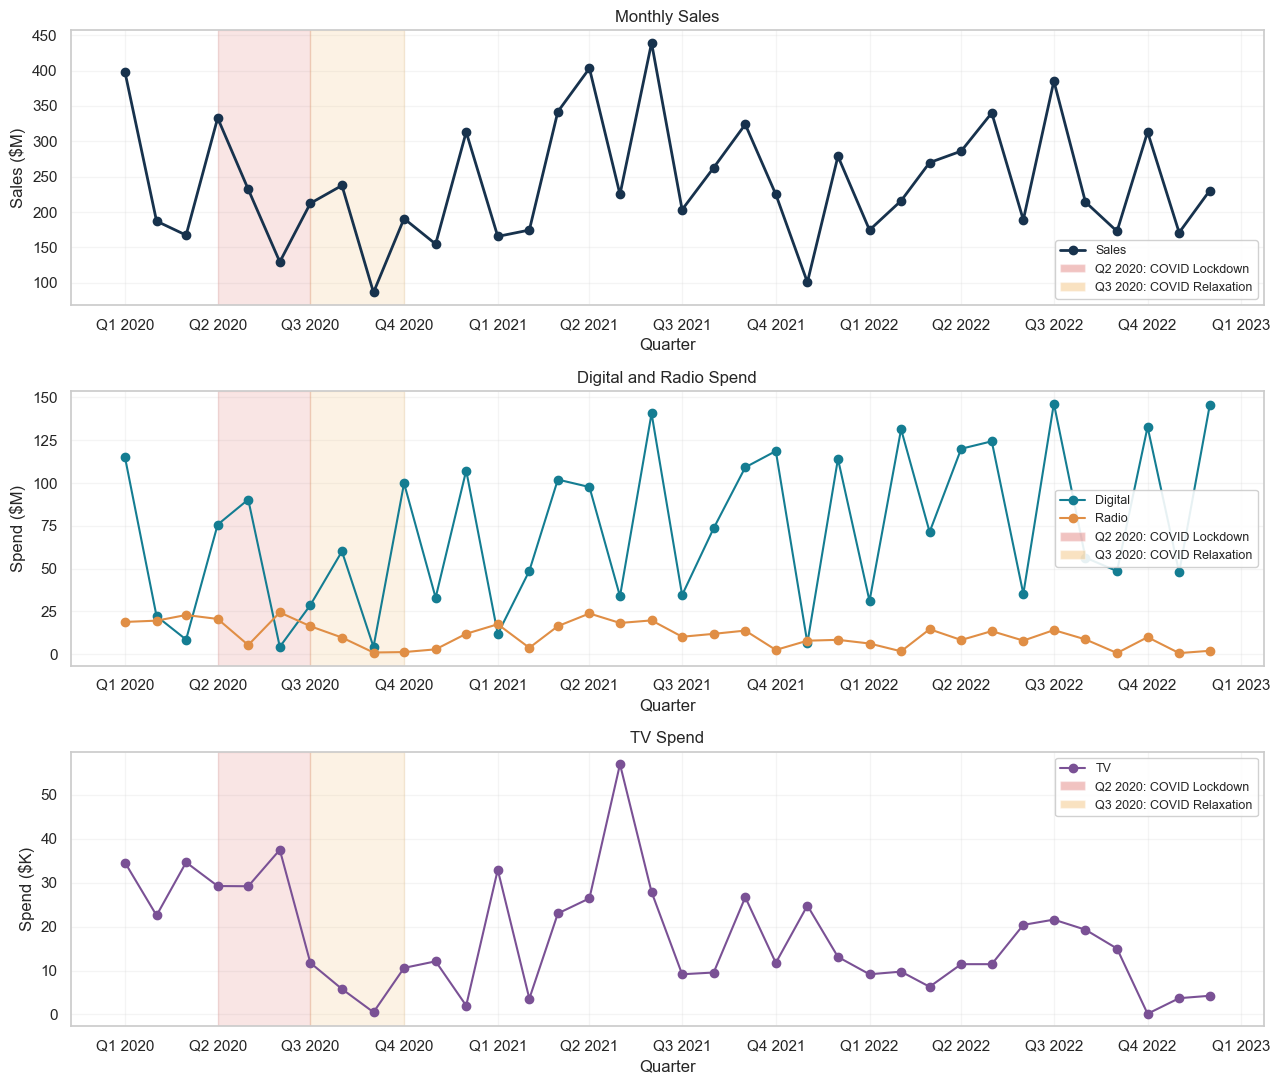

In [10]:

# Create 3 graphs
fig, axes = plt.subplots(
    3, 1, figsize=(13, 11), sharex=True
)

# 1. Monthly sales
axes[0].plot(
    df["date"], df["sales_m"],
    marker="o",
    color=COLORS["sales"],
    linewidth=2,
    label="Sales"
)
axes[0].set_title("Monthly Sales")
axes[0].set_ylabel("Sales ($M)")

# 2. Digital and Radio spend
axes[1].plot(
    df["date"], df["digital_m"],
    marker="o",
    color=COLORS["digital"],
    label="Digital"
)
axes[1].plot(
    df["date"], df["radio_m"],
    marker="o",
    color=COLORS["radio"],
    label="Radio"
)
axes[1].set_title("Digital and Radio Spend")
axes[1].set_ylabel("Spend ($M)")

# 3. TV spend
axes[2].plot(
    df["date"], df["tv_k"],
    marker="o",
    color=COLORS["tv"],
    label="TV"
)
axes[2].set_title("TV Spend")
axes[2].set_ylabel("Spend ($K)")


# Convert dates into quarterly labels
def quarter_formatter(x, pos):
    date = mdates.num2date(x)
    quarter = (date.month - 1) // 3 + 1
    return f"Q{quarter} {date.year}"


# COVID legend definitions
covid_legend = [
    Patch(
        facecolor="#D9534F",
        alpha=0.35,
        label="Q2 2020: COVID Lockdown"
    ),
    Patch(
        facecolor="#F0AD4E",
        alpha=0.35,
        label="Q3 2020: COVID Relaxation"
    )
]


# Apply COVID shading and axis formatting
for ax in axes:

    # RED: COVID lockdown
    ax.axvspan(
        pd.Timestamp("2020-04-01"),
        pd.Timestamp("2020-07-01"),
        color="#D9534F",
        alpha=0.15
    )

    # ORANGE: COVID relaxation
    ax.axvspan(
        pd.Timestamp("2020-07-01"),
        pd.Timestamp("2020-10-01"),
        color="#F0AD4E",
        alpha=0.15
    )

    # Show quarterly ticks
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(bymonth=[1, 4, 7, 10])
    )

    ax.xaxis.set_major_formatter(
        FuncFormatter(quarter_formatter)
    )

    # Show X-axis labels on all graphs
    ax.tick_params(axis="x", labelbottom=True)
    ax.set_xlabel("Quarter")

    # Add grid
    ax.grid(alpha=0.2)

    # Combine line legend with COVID legend
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles=handles + covid_legend,
        loc="best",
        fontsize=9,
        framealpha=0.9
    )

plt.tight_layout()
plt.show()

### 5.2 Average monthly sales by COVID period

,count,mean
covid_phase,,
Q2 2020 lockdown,3,231.600
Q3 2020 relaxation,3,178.800
Other months,30,250.620


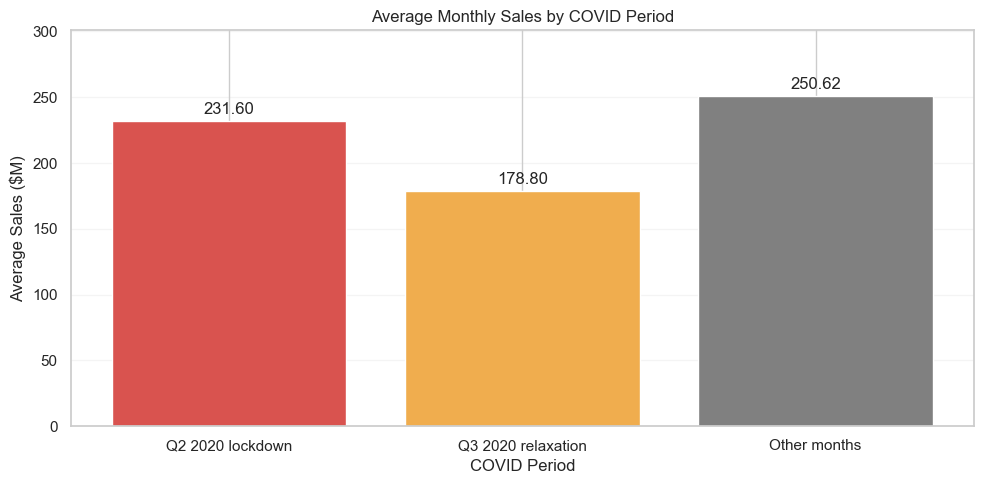

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create COVID period labels
df["covid_phase"] = np.select(
    [
        df["covid_lockdown"] == 1,
        df["covid_relaxation"] == 1
    ],
    [
        "Q2 2020 lockdown",
        "Q3 2020 relaxation"
    ],
    default="Other months"
)

# 2. Define order and colours
order = [
    "Q2 2020 lockdown",
    "Q3 2020 relaxation",
    "Other months"
]

colors = ["#D9534F", "#F0AD4E", "#808080"]

# 3. Calculate average monthly sales
sales_summary = (
    df.groupby("covid_phase")["sales_m"]
    .agg(["count", "mean"])
    .reindex(order)
    .round(2)
)

display(sales_summary)

# 4. Plot average monthly sales
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    order,
    sales_summary["mean"],
    color=colors
)

# Display values above bars
ax.bar_label(bars, fmt="%.2f", padding=3)

ax.set_title("Average Monthly Sales by COVID Period")
ax.set_xlabel("COVID Period")
ax.set_ylabel("Average Sales ($M)")

ax.set_ylim(0, sales_summary["mean"].max() * 1.2)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

### 5.3 Average advertising spend by COVID period

,Months,Digital,Radio,TV
covid_phase,,,,
Q2 2020 lockdown,3,56.830,16.830,31.980
Q3 2020 relaxation,3,31.050,9.080,6.020
Other months,30,78.980,10.710,17.170


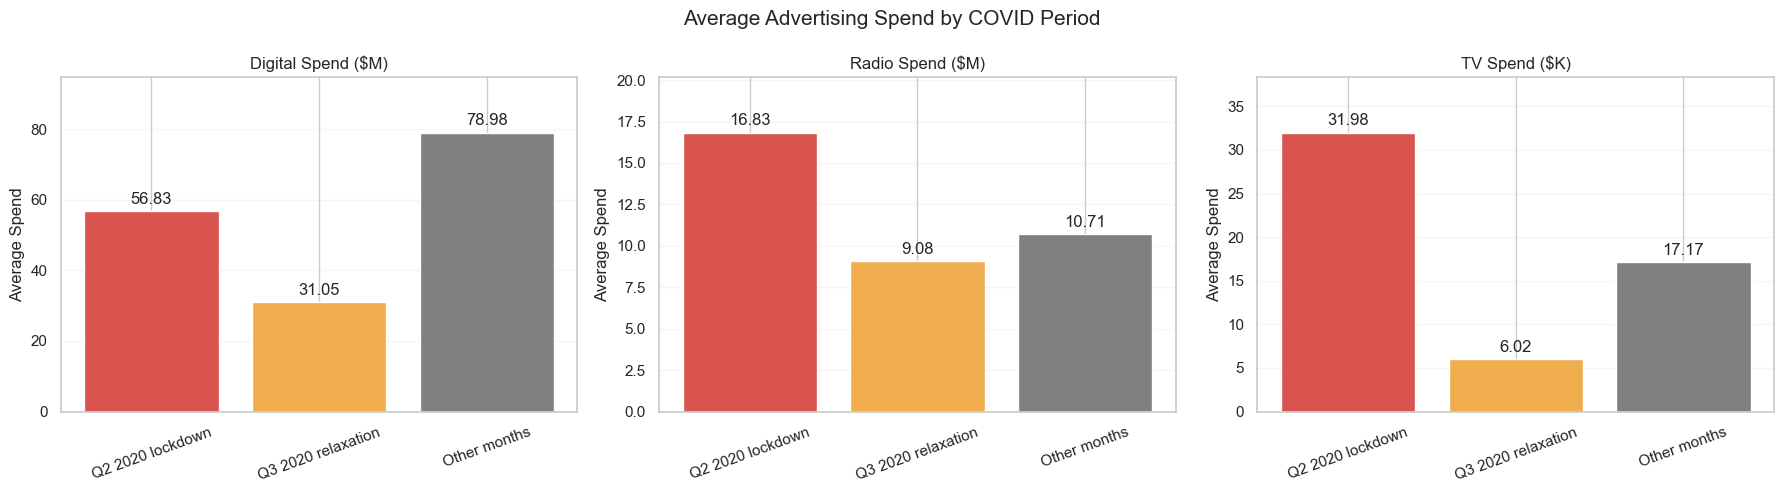

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create COVID period labels
df["covid_phase"] = np.select(
    [
        df["covid_lockdown"] == 1,
        df["covid_relaxation"] == 1
    ],
    [
        "Q2 2020 lockdown",
        "Q3 2020 relaxation"
    ],
    default="Other months"
)

# 2. Define order and colours
order = [
    "Q2 2020 lockdown",
    "Q3 2020 relaxation",
    "Other months"
]

colors = ["#D9534F", "#F0AD4E", "#808080"]

# 3. Calculate average advertising spend
ad_summary = (
    df.groupby("covid_phase")
    .agg(
        Months=("date", "count"),
        Digital=("digital_m", "mean"),
        Radio=("radio_m", "mean"),
        TV=("tv_k", "mean")
    )
    .reindex(order)
    .round(2)
)

display(ad_summary)

# 4. Create three separate advertising charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

channels = [
    ("Digital", "Digital Spend ($M)"),
    ("Radio", "Radio Spend ($M)"),
    ("TV", "TV Spend ($K)")
]

for ax, (column, title) in zip(axes, channels):

    bars = ax.bar(
        order,
        ad_summary[column],
        color=colors
    )

    # Display values above bars
    ax.bar_label(bars, fmt="%.2f", padding=3)

    ax.set_title(title)
    ax.set_ylabel("Average Spend")

    ax.tick_params(axis="x", rotation=20)

    ax.set_ylim(
        0,
        ad_summary[column].max() * 1.2
    )

    ax.grid(axis="y", alpha=0.2)

fig.suptitle(
    "Average Advertising Spend by COVID Period",
    fontsize=15
)

plt.tight_layout()
plt.show()

### 5.4 Pairwise correlations

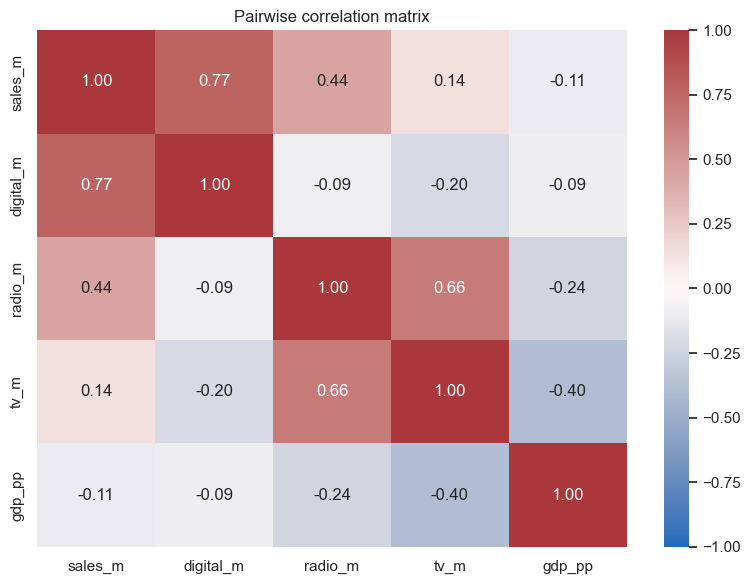

,sales_m
sales_m,1.000
digital_m,0.774
radio_m,0.445
tv_m,0.139
gdp_pp,-0.109


In [13]:
# Pairwise correlations are useful for exploration, but they are not adjusted effects.
corr_cols = ["sales_m", "digital_m", "radio_m", "tv_m", "gdp_pp"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Pairwise correlation matrix")
plt.tight_layout()
plt.show()

display(corr[["sales_m"]].sort_values("sales_m", ascending=False))

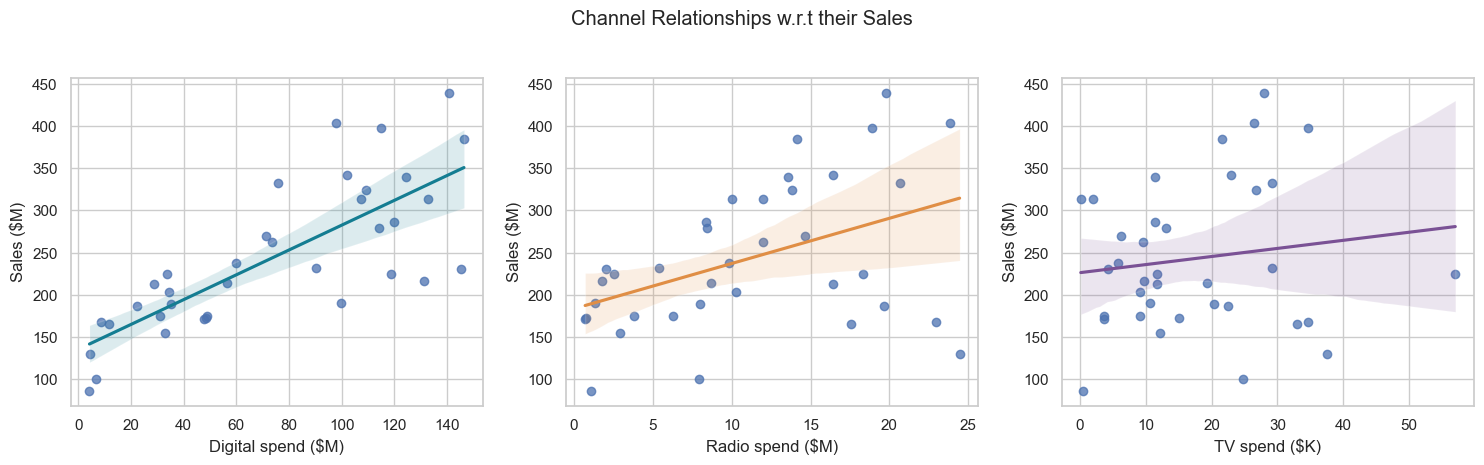

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
channel_specs = [
    ("digital_m", "Digital spend ($M)", COLORS["digital"]),
    ("radio_m", "Radio spend ($M)", COLORS["radio"]),
    ("tv_k", "TV spend ($K)", COLORS["tv"]),
]

for ax, (column, label, color) in zip(axes, channel_specs):
    sns.regplot(data=df, x=column, y="sales_m", ax=ax,
                scatter_kws={"alpha": 0.75}, line_kws={"color": color})
    ax.set_xlabel(label)
    ax.set_ylabel("Sales ($M)")

fig.suptitle("Channel Relationships w.r.t their Sales", y=1.03)
plt.tight_layout()
plt.show()

### 5.5 VIF Regression diagnostics

In [19]:
# Select the same predictors used in Model 1
predictors = [
    "trend", "sin12", "cos12",
    "digital_m", "radio_m", "tv_m"
]

# Add an intercept
X = sm.add_constant(df[predictors].dropna())

# Calculate VIF for each predictor
vif_table = pd.DataFrame({
    "Predictor": predictors,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(1, X.shape[1])
    ]
})

display(vif_table.round(3))

,Predictor,VIF
0,trend,1.498
1,sin12,1.342
2,cos12,1.296
3,digital_m,1.206
4,radio_m,2.391
5,tv_m,1.878


## 6. Hypotheses Test

We use `alpha = 0.05`, but conclusions also consider coefficient size, confidence intervals, diagnostics and business relevance.

| Question | Null hypothesis (H0) | Alternative (H1) |
|---|---|---|
| Overall marketing | Digital = Radio = TV = 0 | At least one channel coefficient is non-zero |
| Individual channel | Channel coefficient = 0 | Channel coefficient is non-zero |
| GDP | GDP coefficient = 0 | GDP coefficient is non-zero |
| COVID lockdown/relaxation | Period coefficient = 0 | Period coefficient is non-zero |

The marketing coefficients are estimated while controlling for the other channels, a linear time trend and compact annual seasonality.

## 6.1 Fit the specified OLS models

### Reusable OLS helper with Newey-West standard errors

This cell contains reusable statistical plumbing. The business workflow remains simple:

`choose columns → fit regression → read coefficient, confidence interval and p-value`

Newey-West standard errors allow mild heteroskedasticity and one-month residual autocorrelation. With only 36 rows, all inferential results remain uncertain.

In [20]:
def fit_ols(data, target, predictors, hac_lag=1):
    # Fit OLS and return coefficients with Newey-West/HAC uncertainty.
    clean = data[[target] + predictors].dropna().copy()
    y = clean[target].to_numpy(dtype=float)
    X = np.column_stack([
        np.ones(len(clean)),
        *[clean[col].to_numpy(dtype=float) for col in predictors]
    ])
    names = ["Intercept"] + predictors

    n, p = X.shape
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    fitted = X @ beta
    residuals = y - fitted
    degrees_freedom = n - p
    sse = float(residuals @ residuals)
    mse = sse / degrees_freedom
    xtx_inverse = np.linalg.pinv(X.T @ X)

    # Newey-West covariance: contemporaneous term plus lagged covariance terms.
    middle = np.zeros((p, p))
    for t in range(n):
        middle += residuals[t] ** 2 * np.outer(X[t], X[t])

    for lag in range(1, hac_lag + 1):
        weight = 1 - lag / (hac_lag + 1)
        for t in range(lag, n):
            cross = np.outer(X[t], X[t - lag])
            middle += weight * residuals[t] * residuals[t - lag] * (cross + cross.T)

    covariance = xtx_inverse @ middle @ xtx_inverse
    covariance *= n / degrees_freedom  # small-sample scaling

    standard_error = np.sqrt(np.maximum(np.diag(covariance), 0))
    t_stat = beta / standard_error
    p_value = 2 * stats.t.sf(np.abs(t_stat), degrees_freedom)
    critical = stats.t.ppf(0.975, degrees_freedom)

    total_sum_squares = float(((y - y.mean()) ** 2).sum())
    r_squared = 1 - sse / total_sum_squares
    adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / degrees_freedom
    aic = n * np.log(sse / n) + 2 * p

    coefficient_table = pd.DataFrame({
        "coefficient": beta,
        "hac_se": standard_error,
        "t_stat": t_stat,
        "p_value": p_value,
        "ci_2.5%": beta - critical * standard_error,
        "ci_97.5%": beta + critical * standard_error,
    }, index=names)

    return {
        "data": clean,
        "target": target,
        "predictors": predictors,
        "names": names,
        "X": X,
        "y": y,
        "beta": beta,
        "covariance": covariance,
        "residuals": residuals,
        "fitted": fitted,
        "df_resid": degrees_freedom,
        "mse": mse,
        "sse": sse,
        "r_squared": r_squared,
        "adjusted_r_squared": adjusted_r_squared,
        "aic": aic,
        "coefficients": coefficient_table,
    }




In [21]:
def joint_wald_test(model, terms):
    # Test whether several coefficients are jointly zero.
    indices = [model["names"].index(term) for term in terms]
    beta = model["beta"][indices]
    covariance = model["covariance"][np.ix_(indices, indices)]
    q = len(indices)

    f_stat = float(beta.T @ np.linalg.pinv(covariance) @ beta / q)
    p_value = float(stats.f.sf(f_stat, q, model["df_resid"]))
    return pd.Series({
        "F statistic": f_stat,
        "numerator df": q,
        "denominator df": model["df_resid"],
        "p-value": p_value,
    })


def holm_adjust(p_values):
    # Holm correction for multiple individual hypothesis tests.
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted_sorted = np.maximum.accumulate(
        (len(p_values) - np.arange(len(p_values))) * p_values[order]
    )
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = np.minimum(adjusted_sorted, 1.0)
    return adjusted


print("Regression helper functions are ready.")

Regression helper functions are ready.


### 6.2 Model specifications and fitting

- **Model 0:** time trend + annual seasonality
- **Model 1:** Model 0 + Digital + Radio + TV
- **Model 2A:** Model 1 + GDP
- **Model 2B:** Model 1 + COVID lockdown and relaxation indicators

GDP and COVID are evaluated in separate extensions because the extreme Q2/Q3 2020 GDP values overlap strongly with the COVID indicators. Putting both in one small model would make their individual effects difficult to separate.

In [22]:
time_controls = ["trend", "sin12", "cos12"]
marketing_terms = ["digital_m", "radio_m", "tv_m"]

model_0 = fit_ols(df, "sales_m", time_controls)
model_1 = fit_ols(df, "sales_m", time_controls + marketing_terms)
model_2_gdp = fit_ols(df, "sales_m", time_controls + marketing_terms + ["gdp_pp"])
model_2_covid = fit_ols(
    df, "sales_m",
    time_controls + marketing_terms + ["covid_lockdown", "covid_relaxation"]
)

model_comparison = pd.DataFrame({
    "Model 0: Time": [model_0["r_squared"], model_0["adjusted_r_squared"], model_0["aic"]],
    "Model 1: + Marketing": [model_1["r_squared"], model_1["adjusted_r_squared"], model_1["aic"]],
    "Model 2A: + GDP": [model_2_gdp["r_squared"], model_2_gdp["adjusted_r_squared"], model_2_gdp["aic"]],
    "Model 2B: + COVID": [model_2_covid["r_squared"], model_2_covid["adjusted_r_squared"], model_2_covid["aic"]],
}, index=["R-squared", "Adjusted R-squared", "AIC"])

display(model_comparison)

,Model 0: Time,Model 1: + Marketing,Model 2A: + GDP,Model 2B: + COVID
R-squared,0.129,0.874,0.881,0.884
Adjusted R-squared,0.047,0.848,0.851,0.849
AIC,323.819,260.157,260.241,261.270


### 6.3  Evaluate the predefined hypotheses using fitted models

#### 6.3.1 Results for A: Overall marketing


In [23]:
overall_marketing_test = joint_wald_test(model_1, marketing_terms)
display(overall_marketing_test.to_frame("result"))

if overall_marketing_test["p-value"] < ALPHA:
    print("Decision: Reject H0. At least one marketing channel is associated with sales.")
else:
    print("Decision: Do not reject H0. The data do not provide sufficient joint evidence.")

,result
F statistic,73.281
numerator df,3.000
denominator df,29.000
p-value,0.000


Decision: Reject H0. At least one marketing channel is associated with sales.


#### 6.3.2 Results for B: Individual channels

In [24]:
channel_results = model_1["coefficients"].loc[marketing_terms].copy()
channel_results["holm_p_value"] = holm_adjust(channel_results["p_value"])
channel_results["significant_after_holm"] = channel_results["holm_p_value"] < ALPHA

# TV coefficient per $1K increase, because the original TV column uses $K.
channel_results["effect_per_source_unit"] = channel_results["coefficient"]
channel_results.loc["tv_m", "effect_per_source_unit"] *= 0.001
channel_results["source_unit"] = ["per $1M Digital", "per $1M Radio", "per $1K TV"]

display(channel_results)

,coefficient,hac_se,t_stat,p_value,ci_2.5%,ci_97.5%,holm_p_value,significant_after_holm,effect_per_source_unit,source_unit
digital_m,1.545,0.173,8.951,0.000,1.192,1.899,0.000,True,1.545,per $1M Digital
radio_m,6.569,1.181,5.562,0.000,4.154,8.985,0.000,True,6.569,per $1M Radio
tv_m,-484.522,384.295,-1.261,0.217,"-1,270.493",301.449,0.217,False,-0.485,per $1K TV


In [25]:
# Collect the existing test results without refitting or changing any model.
test_rows = [{
    "question": "Q1: All media jointly", "H0": "All channel coefficients = 0",
    "test": "Wald/F-type", "statistic": overall_marketing_test["F statistic"],
    "p_value": overall_marketing_test["p-value"],
    "decision_p": overall_marketing_test["p-value"],
}]

tests = [("Q1: " + name.replace("_m", "").title().replace("Tv", "TV"), name, model_1)
         for name in marketing_terms]
tests += [("Q3: GDP", "gdp_pp", model_2_gdp),
          ("Q4: Lockdown", "covid_lockdown", model_2_covid),
          ("Q4: Relaxation", "covid_relaxation", model_2_covid)]
for question, term, model in tests:
    result = model["coefficients"].loc[term]
    # Correct the three channel tests for multiple comparisons.
    decision_p = (channel_results.loc[term, "holm_p_value"]
                  if term in marketing_terms else result["p_value"])
    test_rows.append({
        "question": question, "H0": term + " coefficient = 0",
        "test": "Coefficient t", "statistic": result["t_stat"],
        "p_value": result["p_value"], "decision_p": decision_p,
    })

hypothesis_results = pd.DataFrame(test_rows).set_index("question")
hypothesis_results["decision"] = np.where(
    hypothesis_results["decision_p"] < ALPHA, "Reject H0", "Do not reject H0")
# Scientific notation avoids displaying tiny non-zero p-values as 0.000.
print(hypothesis_results.to_string(float_format=lambda value: f"{value:.4g}"))

# print("\n Conclusion: joint media, Digital and Radio reject H0. TV, GDP and the "
#       "two COVID indicators do not. This does not establish causality or prove zero effects.")

                                                     H0           test  statistic   p_value  decision_p          decision
question                                                                                                                 
Q1: All media jointly      All channel coefficients = 0    Wald/F-type      73.28  1.21e-13    1.21e-13         Reject H0
Q1: Digital                   digital_m coefficient = 0  Coefficient t      8.951 7.659e-10   2.298e-09         Reject H0
Q1: Radio                       radio_m coefficient = 0  Coefficient t      5.562 5.331e-06   1.066e-05         Reject H0
Q1: TV                             tv_m coefficient = 0  Coefficient t     -1.261    0.2174      0.2174  Do not reject H0
Q3: GDP                          gdp_pp coefficient = 0  Coefficient t      1.045    0.3051      0.3051  Do not reject H0
Q4: Lockdown             covid_lockdown coefficient = 0  Coefficient t    -0.9012    0.3754      0.3754  Do not reject H0
Q4: Relaxation         c

Important: Not statistically significant does not mean there is no relationship. It means we lack sufficient evidence to reject H₀ with this dataset and model.

"Our analysis found a statistically significant joint association between advertising and sales. Digital and Radio showed significant positive associations, while TV did not. GDP and the COVID period indicators were also not statistically significant. However, with only 36 observational records, these findings represent associations rather than proven causal effects or marketing ROI."


### Final Hypothesis Testing Results (α = 0.05)

| Hypothesis | Test statistic | p-value | Adjusted p-value | Decision | Business conclusion |
|---|---:|---:|---:|---|---|
| All marketing channels jointly | F = 73.28 | 1.21e-13 | — | Reject H₀ | At least one marketing channel is associated with sales. |
| Digital advertising | t = 8.951 | 7.659e-10 | 2.298e-09 | Reject H₀ | Significant positive adjusted association with sales. |
| Radio advertising | t = 5.562 | 5.331e-06 | 1.066e-05 | Reject H₀ | Significant positive adjusted association with sales. |
| TV advertising | t = -1.261 | 0.2174 | 0.2174 | Do not reject H₀ | Insufficient evidence of an adjusted association. |
| GDP growth | t = 1.045 | 0.3051 | — | Do not reject H₀ | Insufficient evidence of an adjusted GDP association. |
| COVID lockdown | t = -0.9012 | 0.3754 | — | Do not reject H₀ | No statistically detectable adjusted lockdown-period difference. |
| COVID relaxation | t = -0.440 | 0.6635 | — | Do not reject H₀ | No statistically detectable adjusted relaxation-period difference. |

**Notes:**
- Significance level: α = 0.05.
- Holm correction is applied to the three individual advertising-channel tests.
- GDP and COVID indicators are evaluated in separate model extensions.
- Results represent adjusted associations, not proven causal effects.
- Failure to reject H₀ does not prove that an effect is zero.

Digital ranks strongest, followed by Radio. These are adjusted associations—not proof of causal impact or ROI.


In [26]:
# Reuse these predictor lists in the question cells.
time_controls = ["trend", "sin12", "cos12"]
marketing_terms = ["digital_m", "radio_m", "tv_m"]
base_terms = time_controls + marketing_terms

# Time-only benchmark for the presentation's model-comparison graph.
model_0 = fit_ols(df, "sales_m", time_controls)

### 6.4 Confounding assessment: change in channel estimates



In [27]:

standardized = df.copy()
for column in ["sales_m"] + marketing_terms:
    standardized[column] = (
        standardized[column] - standardized[column].mean()
    ) / standardized[column].std(ddof=0)

standardized_model = fit_ols(
    standardized, "sales_m", time_controls + marketing_terms
)

# Start from the full standardized model calculated in Question 2.
full_coefficients = standardized_model["coefficients"]["coefficient"]
confounding_rows = []

for channel in marketing_terms:
    # Omit one control group, while retaining the channel being evaluated.
    groups = {
        "Trend": ["trend"],
        
        "Annual seasonality": ["sin12", "cos12"],
        "Other media": [term for term in marketing_terms if term != channel],
        "All controls": [term for term in base_terms if term != channel],
    }
    for group, omitted in groups.items():
        kept_terms = [term for term in base_terms if term not in omitted]
        reduced = fit_ols(standardized, "sales_m", kept_terms)
        before = reduced["coefficients"].loc[channel, "coefficient"]
        after = full_coefficients[channel]
        confounding_rows.append({
            "channel": channel.replace("_m", "").title().replace("Tv", "TV"),
            "adjustment_added": group,
            "before_adjustment": before,
            "fully_adjusted": after,
            "change": after - before,
            "absolute_change": abs(after - before),
            "sign_changed": np.sign(before) != np.sign(after),
        })

confounding_assessment = pd.DataFrame(confounding_rows)
display(confounding_assessment)

# Describe sensitivity rather than claiming that confounding is proven.
largest = confounding_assessment.loc[confounding_assessment["absolute_change"].idxmax()]
print(f"Largest change: {largest['channel']}, adding {largest['adjustment_added']} "
      f"({largest['change']:+.3f} standardized units).")
print("Conclusion: adjustment changes the estimates; causal confounding remains "
      "a question of study design and business knowledge.")

,channel,adjustment_added,before_adjustment,fully_adjusted,change,absolute_change,sign_changed
0,Digital,Trend,0.812,0.813,0.001,0.001,False
1,Digital,Annual seasonality,0.808,0.813,0.005,0.005,False
2,Digital,Other media,0.842,0.813,-0.028,0.028,False
3,Digital,All controls,0.774,0.813,0.040,0.040,False
4,Radio,Trend,0.547,0.546,-0.001,0.001,False
5,Radio,Annual seasonality,0.565,0.546,-0.018,0.018,False
6,Radio,Other media,0.558,0.546,-0.012,0.012,False
7,Radio,All controls,0.445,0.546,0.101,0.101,False
8,TV,Trend,-0.070,-0.070,-0.000,0.000,False
9,TV,Annual seasonality,-0.061,-0.070,-0.009,0.009,False


Largest change: TV, adding All controls (-0.210 standardized units).
Conclusion: adjustment changes the estimates; causal confounding remains a question of study design and business knowledge.


## Business Questions 

#### Q1: Are all media channels effective in driving sales?

Step 1: Fit the planned marketing model and test the three channels jointly (hypothesis A). A significant joint test means at least one channel is associated with sales. It does not mean all three are effective, or establish causal impact.

In [28]:
# Fit sales against all channels, trend and annual seasonality.
model_1 = fit_ols(df, "sales_m", base_terms)

# Joint test: are all three marketing coefficients zero?
overall_marketing_test = joint_wald_test(model_1, marketing_terms)
display(overall_marketing_test.to_frame("Joint test"))

,Joint test
F statistic,73.281
numerator df,3.000
denominator df,29.000
p-value,0.000


Which individual channels have evidence?

Step 2: Test each channel coefficient (hypothesis B). Holm adjustment accounts for testing three channels. Each coefficient represents the estimated change in sales (dollar million) associated with an additional dollar 1 million spent on that channel, holding the other predictors constant.

In [29]:
# Extract estimates and uncertainty from the fitted marketing model.
channel_results = model_1["coefficients"].loc[marketing_terms].copy()
channel_results["holm_p_value"] = holm_adjust(channel_results["p_value"])
channel_results["significant_after_holm"] = channel_results["holm_p_value"] < ALPHA
display(channel_results[["coefficient", "ci_2.5%", "ci_97.5%",
                         "holm_p_value", "significant_after_holm"]])

# A positive significant association is evidence to investigate, not causal ROI.
supported = channel_results.index[
    (channel_results["coefficient"] > 0) & channel_results["significant_after_holm"]
]
print("Positive adjusted associations after Holm correction:",
      ", ".join(name.replace("_m", "").title() for name in supported))

,coefficient,ci_2.5%,ci_97.5%,holm_p_value,significant_after_holm
digital_m,1.545,1.192,1.899,0.000,True
radio_m,6.569,4.154,8.985,0.000,True
tv_m,-484.522,"-1,270.493",301.449,0.217,False


Positive adjusted associations after Holm correction: Digital, Radio


No—the evidence does not support all three channels being effective.

After controlling for other channels, trend and seasonality:

Digital: positive association, Holm-adjusted p < 0.001.
Radio: positive association, Holm-adjusted p < 0.001.
TV: no statistically significant association, p = 0.217.

Therefore, Digital and Radio have supporting evidence; TV does not. This does not prove TV is ineffective or establish causal impact.

####  Q2. Which is the most important channel

In [30]:
standardized = df.copy()
for column in ["sales_m"] + marketing_terms:
    standardized[column] = (
        standardized[column] - standardized[column].mean()
    ) / standardized[column].std(ddof=0)

standardized_model = fit_ols(
    standardized, "sales_m", time_controls + marketing_terms
)

importance = standardized_model["coefficients"].loc[marketing_terms, [
    "coefficient", "p_value", "ci_2.5%", "ci_97.5%"
]].rename(columns={"coefficient": "standardized_coefficient"})

# Drop one channel at a time to measure its unique contribution.
for channel in marketing_terms:
    reduced_terms = time_controls + [c for c in marketing_terms if c != channel]
    reduced_model = fit_ols(df, "sales_m", reduced_terms)
    importance.loc[channel, "partial_r_squared"] = (
        reduced_model["sse"] - model_1["sse"]
    ) / reduced_model["sse"]

importance["absolute_standardized_effect"] = importance["standardized_coefficient"].abs()
importance = importance.sort_values("absolute_standardized_effect", ascending=False)
display(importance)

# Report the leading channel from the computed ranking.
print("Largest absolute standardized association:",
      importance.index[0].replace("_m", "").title())

,standardized_coefficient,p_value,ci_2.5%,ci_97.5%,partial_r_squared,absolute_standardized_effect
digital_m,0.813,0.000,0.627,0.999,0.813,0.813
radio_m,0.546,0.000,0.345,0.747,0.498,0.546
tv_m,-0.070,0.217,-0.185,0.044,0.021,0.070


Largest absolute standardized association: Digital


Digital is the most important channel based on adjusted association with sales.

Evidence:

Standardized coefficient: Digital 0.813, Radio 0.546, TV −0.070.
Partial R²: Digital 0.813, Radio 0.498, TV 0.021.

Digital is the most important channel, with the highest standardized coefficient (0.813) and partial R² (0.813), followed by Radio and TV.

#### Q3: Do macroeconomic factors influence sales?

In [31]:
# Add GDP to the marketing model, keeping the same time controls.
model_2_gdp = fit_ols(df, "sales_m", base_terms + ["gdp_pp"])
gdp_result = model_2_gdp["coefficients"].loc[["gdp_pp"]]
display(gdp_result[["coefficient", "ci_2.5%", "ci_97.5%", "p_value"]])

# GDP is in percentage points; sales are in millions of dollars.
gdp_p = gdp_result.loc["gdp_pp", "p_value"]
print(f"GDP test p-value: {gdp_p:.3f}")
print("Decision:", "Reject H0" if gdp_p < ALPHA else "Do not reject H0")

,coefficient,ci_2.5%,ci_97.5%,p_value
gdp_pp,0.602,-0.578,1.782,0.305


GDP test p-value: 0.305
Decision: Do not reject H0


No statistically significant GDP–sales relationship was detected after accounting for media spend, trend and seasonality (p = 0.305 > 0.05).

#### Q4 Did COVID affect sales, and why?

In [32]:
# Descriptive comparison: how did sales differ across the defined phases?
df["covid_phase"] = np.select(
    [df["covid_lockdown"].eq(1), df["covid_relaxation"].eq(1)],
    ["Q2 2020 lockdown", "Q3 2020 relaxation"], default="Other months"
)
phase_summary = df.groupby("covid_phase")["sales_m"].agg(["count", "mean", "std"])
display(phase_summary)

# Adjust for media spend, trend and annual seasonality.
covid_terms = ["covid_lockdown", "covid_relaxation"]
model_2_covid = fit_ols(df, "sales_m", base_terms + covid_terms)
covid_results = model_2_covid["coefficients"].loc[covid_terms]
display(covid_results[["coefficient", "ci_2.5%", "ci_97.5%", "p_value"]])

# Report each predefined period comparison separately.
for period, result in covid_results.iterrows():
    decision = "Reject H0" if result["p_value"] < ALPHA else "Do not reject H0"
    print(f"{period}: {decision}, p = {result['p_value']:.3f}")

,count,mean,std
covid_phase,,,
Other months,30,250.620,86.784
Q2 2020 lockdown,3,231.600,101.701
Q3 2020 relaxation,3,178.800,81.007


,coefficient,ci_2.5%,ci_97.5%,p_value
covid_lockdown,-38.334,-125.609,48.940,0.375
covid_relaxation,-9.475,-53.659,34.710,0.663


covid_lockdown: Do not reject H0, p = 0.375
covid_relaxation: Do not reject H0, p = 0.663


No statistically significant COVID-period effect on sales was detected after accounting for media spend, trend and seasonality:

Q2 lockdown: p = 0.375
Q3 relaxation: p = 0.663

Both exceed 0.05. Sales differed across these periods, but the data cannot establish that COVID caused those differences.